In [ ]:
import pandas as pd
import numpy as np

# 1. Skip the complex header rows and read raw data directly
file_fgm = "../data/FGM.xlsx"
df_raw = pd.read_excel(file_fgm, skiprows=9, header=None)

# 2. Extract target columns by index (based on source file structure)
# 0: country, 1: total prevalence, 3: urban, 5: rural, 7: poorest, 9: second, 11: middle, 13: fourth, 15: richest
cols_to_keep = [0, 1, 3, 5, 7, 9, 11, 13, 15]
df_fgm_clean = df_raw.iloc[:, cols_to_keep].copy()

# 3. Assign clear, standardised column names
df_fgm_clean.columns = [
    'country', 
    'fgm_prevalence_total', 
    'fgm_urban', 
    'fgm_rural', 
    'fgm_wealth_poorest', 
    'fgm_wealth_second', 
    'fgm_wealth_middle', 
    'fgm_wealth_fourth', 
    'fgm_wealth_richest'
]

# 4. Clean country column: strip whitespace, remove footnote/summary rows
df_fgm_clean['country'] = df_fgm_clean['country'].astype(str).str.strip()
df_fgm_clean = df_fgm_clean[~df_fgm_clean['country'].str.contains('Notes:|Data refer|y Data|World|Africa|Least developed', case=False, na=False)]
df_fgm_clean = df_fgm_clean[df_fgm_clean['country'] != 'nan']

# 5. Convert numeric columns (replace '-' and other non-numeric values with NaN)
numeric_cols = df_fgm_clean.columns[1:]
for col in numeric_cols:
    df_fgm_clean[col] = pd.to_numeric(df_fgm_clean[col], errors='coerce')

# 6. Sort alphabetically and reset index
df_fgm_clean = df_fgm_clean.sort_values(by='country').reset_index(drop=True)

# 7. Final sanity check
print("FGM Data Cleaning Completed!")
print(f"Total number of countries: {df_fgm_clean['country'].nunique()}")
print("\nMissing values distribution (Validating MNAR hypothesis):")
print(df_fgm_clean.isna().sum())

print("\nFirst 5 rows of the cleaned dataset:")
display(df_fgm_clean.head())

# Save the clean data
df_fgm_clean.to_csv("../data/FGM_clean_english.csv", index=False)

✅ FGM Data Cleaning Completed!
Total number of countries: 213

Missing values distribution (Validating MNAR hypothesis):
country                   0
fgm_prevalence_total    183
fgm_urban               183
fgm_rural               183
fgm_wealth_poorest      185
fgm_wealth_second       185
fgm_wealth_middle       185
fgm_wealth_fourth       185
fgm_wealth_richest      185
dtype: int64

First 5 rows of the cleaned dataset:


,country,fgm_prevalence_total,fgm_urban,fgm_rural,fgm_wealth_poorest,fgm_wealth_second,fgm_wealth_middle,fgm_wealth_fourth,fgm_wealth_richest
0,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Massive Missing Values (183 missing out of 213): there are 183 countries show NaN for FGM prevalence (including countries like Afghanistan and Albania in the .head()). 

This is completely expected and correct. FGM data exhibits textbook MNAR (Missing Not At Random) / Structural Missingness. It is a cultural practice heavily concentrated in Sub-Saharan Africa and parts of the Middle East. UNICEF simply does not survey this metric in Europe, the Americas, or East Asia because it's fundamentally non-existent there.

### Visualization

/var/folders/03/80_k_7_j4717p5lt0d5z92_40000gn/T/ipykernel_65759/3282553845.py:4: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


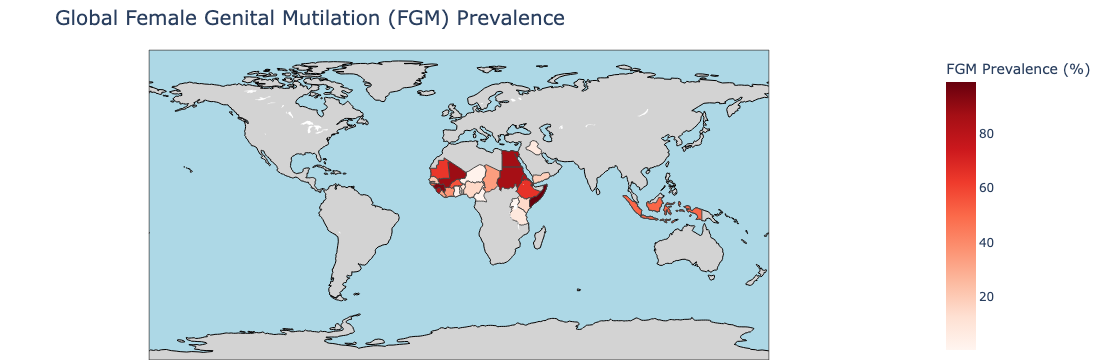

In [ ]:
import plotly.express as px
import plotly.io as pio

# Using the cleaned df_fgm_clean — NaN values will appear as grey on the map
fig = px.choropleth(
    df_fgm_clean,
    locations="country", 
    locationmode="country names",
    color="fgm_prevalence_total",
    hover_name="country",
    color_continuous_scale="Reds",
    title="Global Female Genital Mutilation (FGM) Prevalence",
    labels={'fgm_prevalence_total': 'FGM Prevalence (%)'}
)

# Improve map appearance
fig.update_geos(
    showcoastlines=True, coastlinecolor="Black",
    showland=True, landcolor="lightgrey",
    showocean=True, oceancolor="lightblue"
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    title_font_size=20
)

# Save as static image so it renders on GitHub
fig.write_image("../outputs/fgm_choropleth.png", width=1200, height=600, scale=2)

# Also display inline
fig.show()

The choropleth map visually confirms the structural missingness of FGM data, strongly aligning with specific cultural and geographic distributions.